In [1]:
import sys
import torch
from collections import namedtuple

sys.path.append('../CoMPO-GPT/')

from model_auto import ConditionalTransformer
from utils import read_delimited_file, read_csv_file
import vocabulary as mv

mol_list0_train = list(read_delimited_file('../data/train.smi'))
mol_list0_test = list(read_delimited_file('../data/test.smi'))

mol_list1, target_list = zip(*read_csv_file('../data/excape_all_active_compounds.smi', num_fields=2))
mol_list = mol_list0_train
mol_list.extend(mol_list0_test) 
mol_list.extend(mol_list1)
vocabulary = mv.create_vocabulary(smiles_list=mol_list, tokenizer=mv.SMILESTokenizer())

BATCH_SIZE = 512
SRC_VOCAB_SIZE = len(vocabulary)
TGT_VOCAB_SIZE = len(vocabulary)

EMB_SIZE = 1024
NHEAD = 8
FFN_HID_DIM = 512

NUM_DECODER_LAYERS = 3
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = DEVICE

args = namedtuple('args',['nhead'])(nhead=NHEAD)
emb_len = max([int(t) for t in target_list]) + 1

model = ConditionalTransformer(
    NUM_DECODER_LAYERS, EMB_SIZE, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE,
    FFN_HID_DIM, args=args, emb_input_size=emb_len
)
model.to(device)

model.load_state_dict(torch.load("../weights/finetune.h5_25"))
model.eval()

ConditionalTransformer(
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (linear1): Linear(in_features=1024, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=1024, bias=True)
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
        (dropout3): Dropout(p=0.1, inplac

In [2]:
from model_auto import generate_square_subsequent_mask
import vocabulary as mv

PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2


def topk_filter(scores: torch.FloatTensor, top_k: int = 0, filter_value: float = -float("Inf"), min_tokens_to_keep: int = 1):
    top_k = min(max(top_k, min_tokens_to_keep), scores.size(-1))  # Safety check
     # Remove all tokens with a probability less than the last token of the top-k
    indices_to_remove = scores < torch.topk(scores, top_k)[0][..., -1, None]
    scores = scores.masked_fill(indices_to_remove, filter_value)
    return scores

def greedy_decode(model, max_len, start_symbol, target):
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
    
    for i in range(max_len-1):
        b = 1
        s = max_len
        FFD = 512
        if target == 0:
            _target = torch.zeros((b), dtype=torch.int32).to(device)
        else:
            _target = (torch.ones((b), dtype=torch.int32)*target).to(device)

        tgt_mask = (generate_square_subsequent_mask(ys.size(0))
                                    .type(torch.bool)).to(device)
        out = model.decode(ys, tgt_mask, _target)

        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        pred_proba_t = topk_filter(prob, top_k=30)
        probs = pred_proba_t.softmax(dim=1)
        next_word = torch.multinomial(probs, 1)
        next_word = next_word.item()
        ys = torch.cat([
            ys, torch.ones(1, 1).type_as(ys.data).fill_(next_word)
        ], dim=0)
        if next_word == EOS_IDX:
          break
    return ys

ybar = greedy_decode(
    model, max_len=10, start_symbol=BOS_IDX, target=5
)
ybar_array = ybar.to('cpu').data.numpy().flatten()
smiles = mv.SMILESTokenizer().untokenize(vocabulary.decode(ybar_array))
print(smiles)
print(ybar_array)

CC(=O)c1c
[ 1 18 18  4 16 23  5 55  7 55]


In [20]:
import torch
import torch.nn.functional as F
import numpy as np
from rdkit import Chem

def get_logits_from_model(model, ys, tgt_mask, _target):
    out = model.decode(ys, tgt_mask, _target)
    out = out.transpose(0, 1)
    logits = model.generator(out[:, -1])

    return logits

def decode_get_token_importance(
        model, max_len, start_symbol, target, metric='kl'
    ):
    """
    Decode the model and get the importance of each token.
    The trick is that: for each token, we decode with the target token as the condition 
    and the unconditional (0) token as the condition.
    The importance is given by the KL divergence between the two distributions.
    - KL ≈ 0 → conditioning had no effect
    - KL > 0.5 → significant change
    Or we can use the difference in logits between the target and unconditional token.
    - Δlogit > 0 → conditioning increased confidence in certain outputs
    """
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
    token_importances = []

    for i in range(max_len-1):
        b = 1
        s = max_len
        FFD = 512
        tgt_mask = generate_square_subsequent_mask(
            ys.size(0)
        ).type(torch.bool).to(device)

        # Target token as the condition
        _target = (torch.ones((b), dtype=torch.int32)*target).to(device)
        logits_target = get_logits_from_model(model, ys, tgt_mask, _target)
        
        # Unconditional (0) token as the condition
        _target = torch.zeros((b), dtype=torch.int32).to(device)
        logits_unconditional = get_logits_from_model(model, ys, tgt_mask, _target)
        
        if metric == 'kl':
            # KL divergence
            importance = (
                F.softmax(logits_target, dim=1) * (
                    F.softmax(logits_target, dim=1).log() - 
                    F.softmax(logits_unconditional, dim=1).log()
                )
            ).sum(-1)
        
        elif metric == 'sad':
            top_class = logits_target.argmax(dim=-1)
            top_class_logits_cond = logits_target.gather(-1, top_class.unsqueeze(-1)).squeeze(-1)
            top_class_logits_uncond = logits_unconditional.gather(-1, top_class.unsqueeze(-1)).squeeze(-1)
            delta = top_class_logits_cond - top_class_logits_uncond
            importance = delta.abs()
        
        token_importances.append(importance)
        pred_proba_t = topk_filter(logits_target, top_k=30)
        probs = pred_proba_t.softmax(dim=1)
        next_word = torch.multinomial(probs, 1)
        next_word = next_word.item()
        ys = torch.cat([
            ys, torch.ones(1, 1).type_as(ys.data).fill_(next_word)
        ], dim=0)
        if next_word == EOS_IDX:
          break

    return ys, token_importances

target, target_idx = "D2R", 2

ybar, importance = decode_get_token_importance(
    model, max_len=100, start_symbol=BOS_IDX, target=target_idx, metric='kl'
)
ybar_array = ybar.to('cpu').data.numpy().flatten()
smiles = mv.SMILESTokenizer().untokenize(vocabulary.decode(ybar_array))
print(smiles)
print(ybar_array)
importance_np = np.concatenate(
    [i.cpu().detach().numpy() for i in importance]
)

is_smiles_valid = Chem.MolFromSmiles(smiles) is not None
print(is_smiles_valid)

# ybar_array contains BOS and EOS (N+2 tokens)
# importance_np contains EOS (N+1 tokens)
# smiles does not contain neither BOS nor EOS (N tokens, assuming 1 token per char)
len(ybar_array), len(importance_np), len(smiles)

CCCNCC1CCc2c(OC)cccc2C1
[ 1 18 18 18 22 18 18  7 18 18 55  8 55  4 23 18  5 55 55 55 55  8 18  7
  2]
True


(25, 24, 23)

/home/arthurcerveira/miniconda3/envs/aidd/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/arthurcerveira/miniconda3/envs/aidd/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


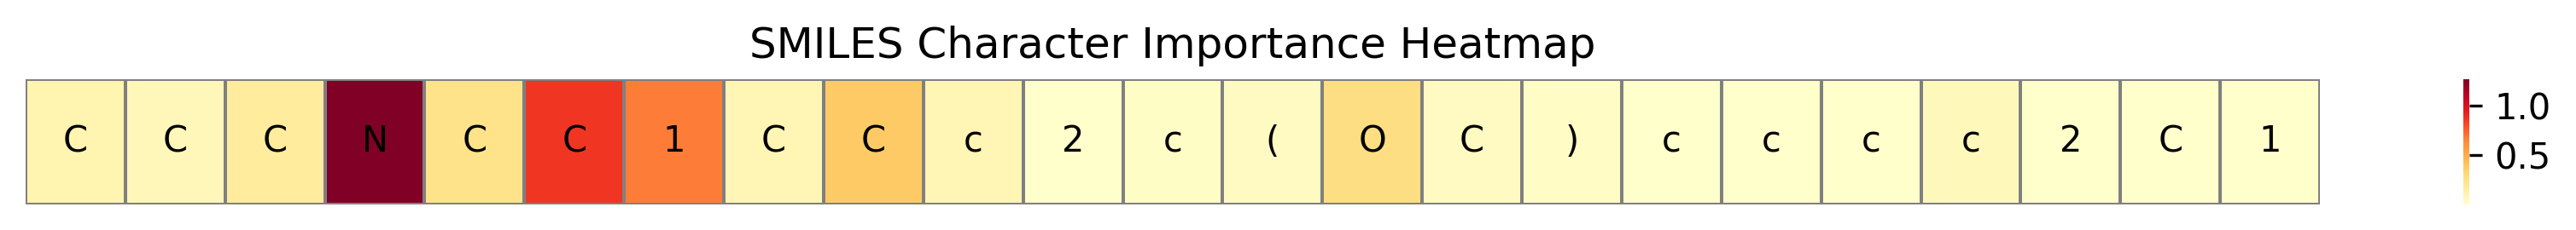

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def smiles_heatmap(ybar: list, importance_np: np.ndarray, cmap='YlOrRd'):
    smiles = list()
    for i in ybar:
        smiles.append(vocabulary.decode([i])[0])

    # Reshape to 2D (1 row, N columns)
    data = importance_np.reshape(1, -1)

    # Plot
    plt.figure(figsize=(max(6, len(smiles) * 0.5), 1), dpi=300)
    ax = sns.heatmap(data, cmap=cmap, cbar=True, xticklabels=list(smiles), yticklabels=False,
                     linewidths=0.5, linecolor='gray')
    
    # Write the importance values on the heatmap
    for i, (char, imp) in enumerate(zip(smiles, importance_np)):
        ax.text(i+0.5, 0.5, f"{char}", ha='center', va='center', color='black')


    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])

    ax.set_title(f"SMILES Character Importance Heatmap")
    plt.tight_layout()
    plt.show()

# Remove the first and last token (BOS and EOS) from ybar_array
# and the last importance token (EOS) from importance_np
smiles_heatmap(ybar_array[1:-1], importance_np[:-1])

In [37]:
def smiles_barchart(ybar: list, importance_np: np.ndarray, save: bool = False):
    smiles = list()
    for i in ybar:
        smiles.append(vocabulary.decode([i])[0])

    # Create bar chart
    plt.figure(figsize=(max(6, len(smiles) * 0.35), 2.5), dpi=350)  # Increased height
    plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    # plt.axhline(y=2, color='gray', linestyle='--', alpha=0.5)

    # Plot bars
    bars = plt.bar(range(len(smiles)), importance_np, color='#3d85c6ff')
    
    # Add value labels on top of each bar
    for i, (bar, char) in enumerate(zip(bars, smiles)):
        height = bar.get_height()
        text = f'{height:.1f}' if height > 0.1 else ''
        plt.text(bar.get_x() + bar.get_width()/2., height,
                text,
                ha='center', va='bottom')
        # Add character labels on x-axis with more padding
        plt.text(bar.get_x() + bar.get_width()/2., -0.1,  # Increased padding
                f'{char}',
                ha='center', va='top')
    
    plt.title("Token Importance Conditioned on Dopamine D2 Receptor Binding Affinity")
    plt.xlabel("Generated SMILES Token", labelpad=25)  # Added labelpad
    plt.ylabel("Importance Score")
    plt.yticks([])
    plt.xticks([])
    plt.grid(False)
    plt.box(False)
    plt.margins(y=0.2)  # Add margin at bottom

    if save:
        # Save as SVG
        plt.savefig("Example.png", dpi=350, bbox_inches='tight')
        plt.close()
        return
    plt.show()
        

# Remove the first and last token (BOS and EOS) from ybar_array
# and the last importance token (EOS) from importance_np
smiles_barchart(ybar_array[1:-1], importance_np[:-1], save=True)

In [27]:
from copy import deepcopy
import numpy as np
from rdkit import Chem
# Disable RDKit warnings
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')


substitution_groups = {
    'C': ['N', 'O', 'S'],
    'N': ['C', 'O'],
    'O': ['N', 'S'],
    'S': ['O', 'N'],
    'F': ['Cl', 'Br'],
    'Cl': ['F', 'Br'],
    'Br': ['Cl', 'I'],
    'I': ['Br'],
    'n': ['c'],
    'c': ['n', 'o'],
    'o': ['c', 'n']
}

substitution_groups_idx = {
    vocabulary._tokens[token] : [vocabulary._tokens[sub_token] for sub_token in substitution_groups[token]] 
    for token in substitution_groups
}

atoms_tokens_idx = np.array(list(substitution_groups_idx.keys()))

def perturb_most_important_atom_token(ybar_array: str, importances: np.ndarray):
    """
    Generate a new SMILES by perturbing the most important atom token.
    Search for reasonable substitutions using chemically-informed substitution groups.
    Return all possible perturbations.
    """
    # Find indices where ybar_array contains atom tokens
    atom_token_mask = np.isin(ybar_array, atoms_tokens_idx)
    # Get importance values only for atom tokens
    atom_importance = np.where(atom_token_mask, importances, -np.inf)

    # Find the most important atom token
    most_important_token_idx = np.argmax(atom_importance)
    most_important_token = ybar_array[most_important_token_idx]
    valid_perturbations = []

    possible_tokens = substitution_groups_idx[most_important_token]

    for token in possible_tokens:
        new_y_bar = deepcopy(ybar_array)
        new_y_bar[most_important_token_idx] = token
        new_smiles = mv.SMILESTokenizer().untokenize(vocabulary.decode(new_y_bar))

        # Check if the new SMILES is valid
        molecule = Chem.MolFromSmiles(new_smiles)
        if not molecule:
            continue
        
        new_y_bar = np.concatenate([[BOS_IDX], new_y_bar, [EOS_IDX]], axis=0)
        valid_perturbations.append(new_y_bar)

    return valid_perturbations

valid_perturbations = perturb_most_important_atom_token(ybar_array[1:-1], importance_np[:-1])
print(smiles)

for perturbed_ybar in valid_perturbations:
    new_smiles = mv.SMILESTokenizer().untokenize(vocabulary.decode(perturbed_ybar))
    print(new_smiles)

CCCNCC1CCc2c(OC)cccc2C1
CCCCCC1CCc2c(OC)cccc2C1
CCCOCC1CCc2c(OC)cccc2C1


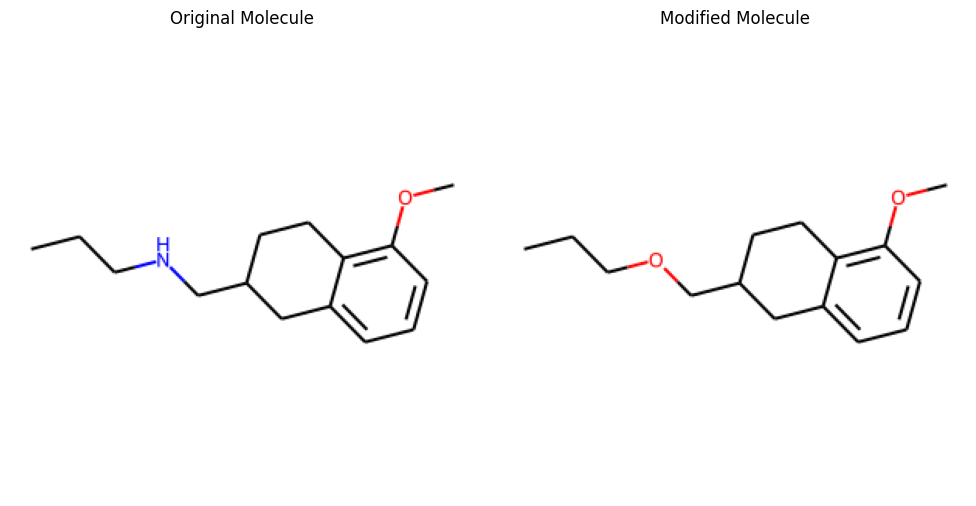

In [43]:
# Visualize smiles and new_smiles
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# Create RDKit molecules
mol1 = Chem.MolFromSmiles(smiles)
mol2 = Chem.MolFromSmiles(new_smiles)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

# Draw the molecules
img1 = Draw.MolToImage(mol1, fitImage=True)
img2 = Draw.MolToImage(mol2)

# Display the images
ax1.imshow(img1)
ax1.set_title('Original Molecule')
ax1.axis('off')

ax2.imshow(img2) 
ax2.set_title('Modified Molecule')
ax2.axis('off')

plt.tight_layout()
plt.show()

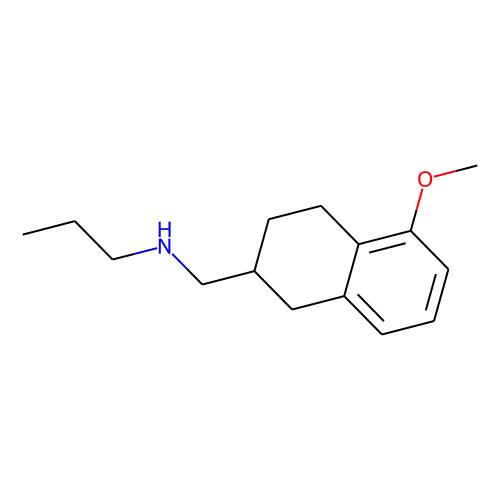

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

# Create a molecule object
mol = Chem.MolFromSmiles(smiles)

# Define the drawing dimensions
width = 500
height = 500

# Create a MolDraw2DSVG object
drawer = rdMolDraw2D.MolDraw2DSVG(width, height)

# Draw the molecule
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

# Get the SVG text and display it (e.g., in a Jupyter Notebook)
svg_text = drawer.GetDrawingText()
SVG(svg_text)

In [29]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from rdkit import RDLogger
import sys

CURRENT_DIR = Path(".").resolve().parent
os.chdir(CURRENT_DIR / "./chemprop")

import chemprop

arguments = [
    '--test_path', '/dev/null',
    '--preds_path', '/dev/null',
    '--checkpoint_dir', f'../models_chemprop/{target}-pXC50-checkpoint',
]

smiles_input = [[smiles], [new_smiles]]
args = chemprop.args.PredictArgs().parse_args(arguments)
preds = chemprop.train.make_predictions(args=args, smiles=smiles_input)

np.array(preds).flatten()

Loading training args
Setting molecule featurization parameters to default.
Loading data
Validating SMILES
Test size = 2


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Moving model to cuda


100%|██████████| 1/1 [00:00<00:00,  2.28it/s]

Saving predictions to /dev/null
Elapsed time = 0:00:01


array([6.44366021, 6.20025268])

In [ ]:
# mols_and_perturbations = dict()
# N = 10

# for i in range(N):
#     ybar = greedy_decode(
#         model, max_len=10, start_symbol=BOS_IDX, target=5
#     )
#     ybar_array = ybar.to('cpu').data.numpy().flatten()
#     smiles = mv.SMILESTokenizer().untokenize(vocabulary.decode(ybar_array))
